<a href="https://colab.research.google.com/github/Mikhailo88/KSVDKyrs3/blob/main/%D0%9B%D0%B0%D0%B16%D0%9E%D0%BB%D1%8C%D1%85%D0%BE%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import math


# Клас для двовимірної L-системи
class LSystem2D:
    def __init__(self, axiom, width, length, angle):
        self.axiom = axiom           # Початковий рядок
        self.state = axiom           # Поточний стан
        self.width = width           # Товщина лінії
        self.length = length         # Довжина одного сегмента
        self.angle = angle           # Кут повороту
        self.rules = {}              # Правила переписування

    # Додаємо правила переписування
    def add_rules(self, *rules):
        for key, value in rules:
            self.rules[key] = value

    # Генерація нового шляху на основі ітерацій
    def generate_path(self, n_iter):
        for _ in range(n_iter):
            new_state = ""
            for char in self.state:
                if char in self.rules:
                    new_state += self.rules[char].lower()  # щоб уникнути повторної заміни
                else:
                    new_state += char
            self.state = new_state.upper()  # Повертаємо до верхнього регістру

    # Малювання через matplotlib
    def draw_turtle(self, start_pos, start_angle):
        x, y = start_pos
        current_angle = start_angle

        lines_x = []
        lines_y = []

        for move in self.state:
            if move == 'F':  # Малюємо лінію вперед
                new_x = x + self.length * math.cos(math.radians(current_angle))
                new_y = y + self.length * math.sin(math.radians(current_angle))

                lines_x.extend([x, new_x, None])
                lines_y.extend([y, new_y, None])

                x, y = new_x, new_y

            elif move == 'S':  # Переміщення без сліду
                x = x + self.length * math.cos(math.radians(current_angle))
                y = y + self.length * math.sin(math.radians(current_angle))

            elif move == '+':  # Поворот вліво
                current_angle += self.angle

            elif move == '-':  # Поворот вправо
                current_angle -= self.angle

        plt.figure(figsize=(14, 7))
        plt.plot(lines_x, lines_y, linewidth=self.width)
        plt.axis("equal")
        plt.axis("off")
        plt.show()

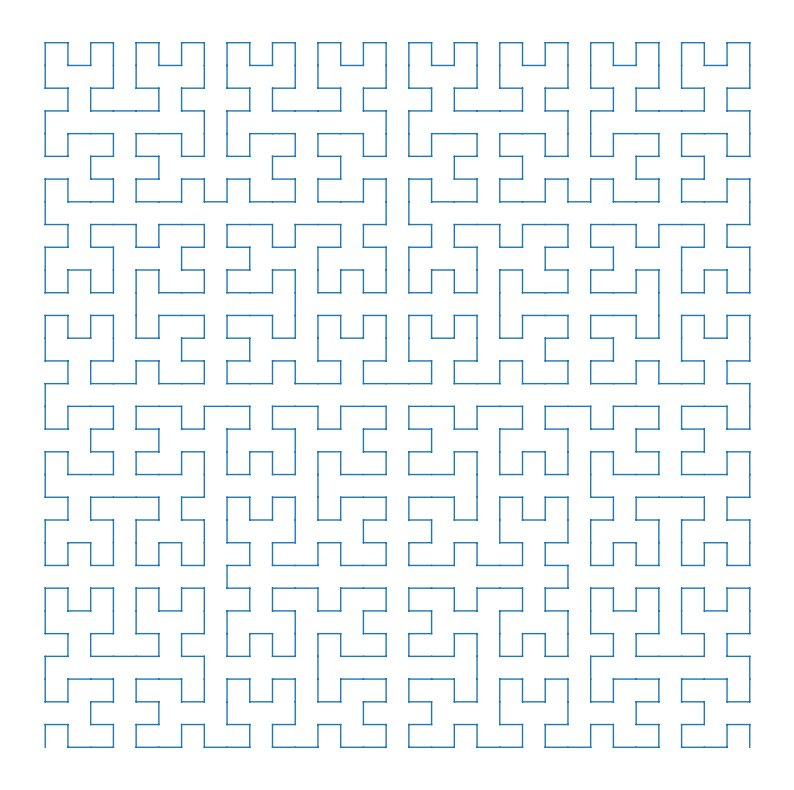

In [ ]:
import matplotlib.pyplot as plt
import math

axiom = "A"
angle = 90

l_sys = LSystem2D(axiom, 1, 5, angle)
l_sys.add_rules(
    ("A", "+BF-AFA-FB+"),
    ("B", "-AF+BFB+FA-")
)

l_sys.generate_path(5)
l_sys.draw_turtle((0, 0), 0)

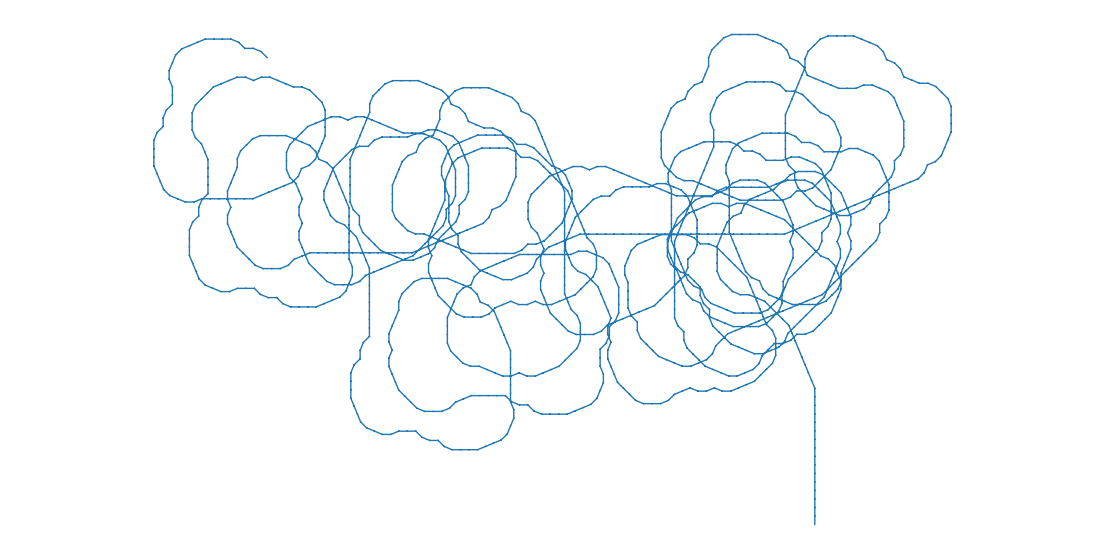

In [ ]:
axiom = "X"
angle = 22.5

l_sys = LSystem2D(axiom, 1, 3, angle)
l_sys.add_rules(
    ("X", "F+[[X]-X]-F[-FX]+X"),
    ("F", "FF")
)

l_sys.generate_path(5)
l_sys.draw_turtle((0, 0), 90)

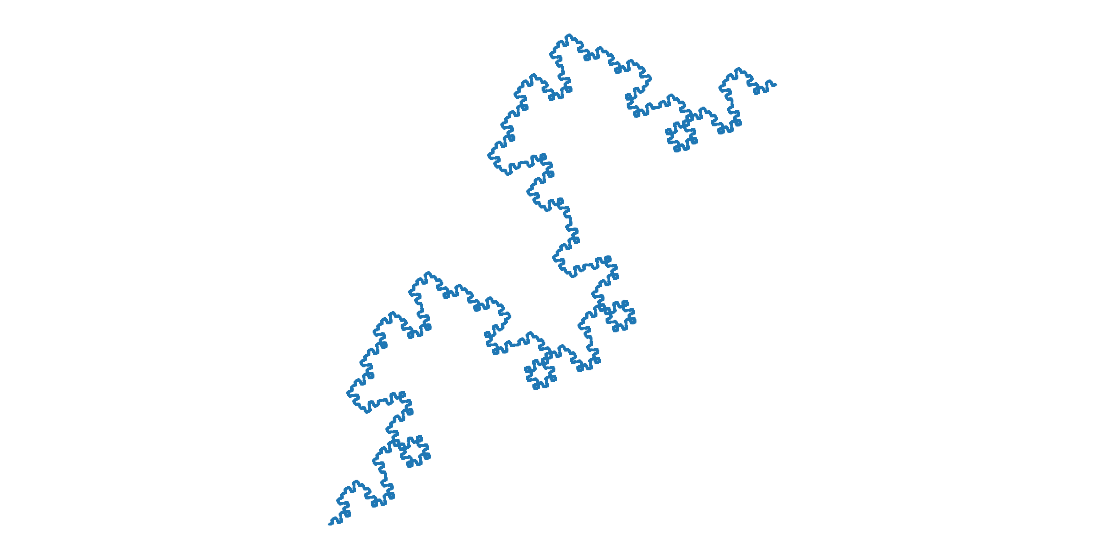

In [ ]:
axiom = "F"
angle = 89  # спеціально не 90

l_sys = LSystem2D(axiom, 1, 4, angle)
l_sys.add_rules(
    ("F", "F+F-F-F+F+FF-F-F+F")
)

l_sys.generate_path(4)
l_sys.draw_turtle((0, 0), 0)